¡Hola!

Mi nombre es Marcos Torres y tengo el gusto de revisar tu código el día de hoy.

Cuando vea algo notable o algún asunto en el notebook, te dejaré un comentario o un hint. Se que encontraras la mejor respuesta para resolver todos los comentarios, de no ser así, no te preocupes en futuras iteraciones dejaré comentarios y pistas más específicos.

Encontrarás comentarios en verde, amarillo o rojo como los siguientes:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo. ¡Lo hiciste muy bien!
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Nota. Se puede mejorar.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesitas corregirlo. Este bloque indica que se requiere una correción. El trabajo no se acepta si tiene estos bloques.
</div>

Puedes responder a mis comentarios usando estos bloques:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.


📌Proposito del proyecto:

Las telecomunicaciones Megaline quiere saber que plan de los que ofreen genra mayores ganancia, de esto depende que medidas van a implementar en su publicidad, incluso puede ayudarle a si estos planes no son suficientes, podrian generan un nuevo tipo de plan para sus usuarios


(Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de los planes genera más ingresos para poder ajustar el presupuesto de publicidad.)




## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np

# Ahora lo graficas
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_calls= pd.read_csv('/datasets/megaline_calls.csv') 
df_internet= pd.read_csv('/datasets/megaline_internet.csv') 
df_messages=pd.read_csv('/datasets/megaline_messages.csv') 
df_plans =pd.read_csv('/datasets/megaline_plans.csv')
df_users =pd.read_csv('/datasets/megaline_users.csv') 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, usaste correctamente una celda independiente para importar las librerías y otra para leer los datos.
</div>

## Preparar los datos

In [3]:
print('*' * 80)
print('*' * 40 +'df_calls' + '*' * 40)
display(df_calls.head())
print('*' * 80)
print(df_calls.info())
print('*' * 80)
print('cuenta con valores null--->', df_calls.isnull().sum())
print('*' * 80)
print('*' * 80)
print('*' * 40 +'df_internet' + '*' * 40)
display(df_internet.head())
print('*' * 80)
print(df_internet.info())
print('*' * 80)
print('cuenta con valores null--->', df_internet.isnull().sum())
print('*' * 80)
print('*' * 80)
print('*' * 40 +'df_messages' + '*' * 40)
display(df_messages.head())
print('*' * 80)
print(df_messages.info())
print('*' * 80)
print('cuenta con valores null--->', df_messages.isnull().sum())
print('*' * 80)
print('*' * 80)
print('*' * 40 +'df_plans' + '*' * 40)
display(df_plans.head())
print('*' * 80)
print(df_plans.info())
print('*' * 80)
print('cuenta con valores null--->', df_plans.isnull().sum())
print('*' * 80)
print('*' * 80)
print('*' * 40 +'df_users' + '*' * 40)
display(df_users.head())
print('*' * 80)
print(df_users.info())
print('*' * 80)
print('cuenta con valores null--->', df_users.isnull().sum())

********************************************************************************
****************************************df_calls****************************************


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
********************************************************************************
cuenta con valores null---> id           0
user_id      0
call_date    0
duration     0
dtype: int64
********************************************************************************
********************************************************************************
****************************************df_internet****************************************


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
********************************************************************************
cuenta con valores null---> id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
********************************************************************************
********************************************************************************
****************************************df_messages****************************************


...

********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
********************************************************************************
cuenta con valores null---> id              0
user_id         0
message_date    0
dtype: int64
********************************************************************************
********************************************************************************
****************************************df_plans****************************************


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None
********************************************************************************
cuenta con valores null---> messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


********************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
********************************************************************************
cuenta con valores null---> user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen uso de los métodos de pandas para explorar los datos.
</div>

📌en la  ultima tabla: df_users, se observa que  solo 34 dice que no son null, pero como decia en el diccionario "si el valor es ausente, la tarifa se estaba usando cuando fue extraída esta base de datos", por lo que se da a entender, que solo 34 personas se dieron de baja, o no estaban usando el servicio en ese momento, por lo que no importa, ambos paquetes tienen mucha solicitud.

## Tarifas

In [4]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [5]:
# Imprime una muestra de los datos para las tarifas

display(df_plans.head())


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


📌Se pensaria que esta mal los datos de la columna, que es importante: los GB de datos que se incluye para cada paquete, para el pequete de Surf, se incluye 15 GB, si 1 GB = 1024 mrgabytes 15*1024=15,360  y asi para el otro paquete, pero como menciona que se ponen en megabytes, esta bien, solo se deja el antecedente, como observación


## Corregir datos

📌 no estoy segura de que deba corregir datos, ya que  de df_internet,  en (mb_used) se cuenta con 13,747 registros con 0.00 lo cual se me hace incongruente, y deberia de revisarse realmente cuanto datos se ha gastado, si no se hubiera gastado datos, no deberia de existir ni siquiera el registro

In [6]:

print('*' * 80)

print('*' * 40 +'df_internet' + '*' * 40)
df_internet.info()
display(df_internet.head())
print(f"hay tantos registro con valor de 0.00 en GB---> {(df_internet['mb_used'] == 0.00).sum()}")  # Devuelve cuántos True hay
print('*' * 80)

print('*' * 80)
df_internet['mb_used'].value_counts()
#porcentaje = (parte / total) * 100
print(f"porcentaje--->{((13747/104825) * 100)}")


********************************************************************************
****************************************df_internet****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


hay tantos registro con valor de 0.00 en GB---> 13747
********************************************************************************
********************************************************************************
porcentaje--->13.11423801574052


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Muy bien! Se trato correctamente la tabla de tarifas.
</div>

## Enriquecer los datos

📌 como se menciona que la tabla df_users que el valor es ausente por que se estaba usando, por lo que no se le ve sentido el quitar esos registro o poner algo, se concsidera que todos esos usuarios, siguen con el servicio, si no fuera asi, deberiamos contar con una tabla de usarios dados de baja para poder dejar mas consolidad la informacion

In [7]:
#' dejo esta celda, pero no creo que sea necesaria, la dejo por si debo quitar cosas'

## Usuarios/as

In [8]:
# Imprime la información general/resumida sobre el DataFrame de usuarios


print('*' * 80)
print('*' * 40 +'usuarios' + '*' * 40)
df_users.info()

********************************************************************************
****************************************usuarios****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [9]:
# Imprime una muestra de datos para usuarios

display(df_users.head())
print(f"hay tantos registro con valor de NaN---> {df_users['churn_date'].isna().sum()}")  # Devuelve cuántos True hay
print('*' * 80)
#porcentaje = (parte / total) * 100
print(f"porcentaje--->{((34/500) * 100)}")
display(df_users.sample(n=15))  # Devuelve 5 filas aleatorias
print('*' * 80)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


hay tantos registro con valor de NaN---> 466
********************************************************************************
porcentaje--->6.800000000000001


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
98,1098,Collin,Sims,33,"Albany-Schenectady-Troy, NY MSA",2018-08-14,surf,NaN
14,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,NaN
460,1460,Winford,Underwood,46,"Fresno, CA MSA",2018-05-28,ultimate,NaN
491,1491,Terina,Jensen,22,"Grand Rapids-Kentwood, MI MSA",2018-04-27,surf,2018-09-18
108,1108,Porfirio,Kane,45,"Salt Lake City, UT MSA",2018-12-30,ultimate,NaN
91,1091,Taylor,Oliver,38,"Riverside-San Bernardino-Ontario, CA MSA",2018-05-04,ultimate,NaN
160,1160,Steven,Morgan,44,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-02-05,surf,NaN
131,1131,Shane,Morrison,60,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-01-07,surf,NaN
427,1427,Zofia,Brock,64,"Washington-Arlington-Alexandria, DC-VA-MD-WV MSA",2018-01-26,ultimate,NaN
142,1142,Charlesetta,Dillard,18,"New Orleans-Metairie, LA MSA",2018-08-23,surf,NaN


********************************************************************************


📌como ya se habia mencionado, se tienen solo  34 valores para churn_date, hay datos ausentes, como en el dicionario de datos se menciono, todos los demas registros estaban ocupados, y por eso no se pudo obtener, al ser tantos, lo mejor seria solicitar una acalaracion:
-  Como que fecha es el respaldo, o solicitar mas información, o que proporciones la fecha o que agreguen un campo como bandera para saber  si son usuarios que estan dados de baja, o si son usuarios activos aun.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, usaste correctamente los prints para mostrar las exploraciones.
</div>

### Corregir los datos

📌yo obtaria por ignorar la columna churn_date, ya que no me esta aportando, y como dice se estaba usando y no esta agregando o no depende ninguna otra informacion de ella, por si la necesito despues trabajare con una copia

In [10]:
df_users_aux=df_users.drop('churn_date', axis=1)
display(df_users_aux.head())

,user_id,first_name,last_name,age,city,reg_date,plan
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf


### Enriquecer los datos

In [11]:
# de momento no

## Llamadas

In [12]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

df_calls.info()
print('*' * 80)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
********************************************************************************


In [13]:
# Imprime una muestra de datos para las llamadas

print('*' * 80)
display(df_calls.head())

print('*' * 80)
display(df_calls.sample(n=15))  # Devuelve 5 filas aleatorias

********************************************************************************


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


********************************************************************************


,id,user_id,call_date,duration
127495,1456_420,1456,2018-09-05,6.33
108538,1383_114,1383,2018-11-05,15.22
120156,1418_40,1418,2018-12-23,18.91
137494,1498_431,1498,2018-08-02,2.82
34871,1132_170,1132,2018-06-21,9.73
119920,1417_671,1417,2018-09-14,0.00
72386,1257_126,1257,2018-10-16,12.70
77848,1278_261,1278,2018-12-26,1.98
56228,1201_328,1201,2018-08-10,0.11
46221,1167_304,1167,2018-10-22,15.51


📌Aparentemente todo se ve bien, pero despues de realizar un aleatorio de un poco mas de 5 datos se ve que hay registros de llamadas con 0 .0 segundos de duracion, estos  no debieron de registrarse, por lo que seria mas conveniente el eliminarlos, esto no afectaria como en el  otro caso de que eran 

### Corregir los datos

In [14]:

#print((df_calls['duration'] == 0.00) and df_calls['user_id'] == 1327)  # Devuelve cuántos True hay
print(((df_calls['duration'] == 0.00) & (df_calls['user_id'] == 1327)).sum())

print('*' * 80) 


# Filtra el DataFrame
filtro = (df_calls['duration'] == 0.00) & (df_calls['user_id'] == 1327)
print('*' * 80) 
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro.sum()}')
print('*' * 80) 
# Muestra los registros que cumplen la condición
print(df_calls[filtro])


print('*' * 80) 


# Filtra el DataFrame
filtro = (df_calls['duration'] != 0.00) & (df_calls['user_id'] == 1327)


# Filtra el DataFrame
filtro2 = (df_calls['user_id'] == 1327)
print('*' * 80) 
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro2.sum()}')
print('*' * 80) 
print('*' * 80) 

# Filtra el DataFrame
filtro3 = df_calls['duration'] == 0.00 


print('*' * 80) 
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados que la duracion de llamada: {filtro3.sum()}' + 'contra tantos registros:137735 ')
print('*' * 80) 

55
********************************************************************************
********************************************************************************
Total de registros encontrados: 55
********************************************************************************
             id  user_id   call_date  duration
90075    1327_0     1327  2018-10-17       0.0
90094   1327_19     1327  2018-11-03       0.0
90095   1327_20     1327  2018-08-26       0.0
90101   1327_26     1327  2018-11-23       0.0
90102   1327_27     1327  2018-11-02       0.0
90111   1327_36     1327  2018-08-31       0.0
90112   1327_37     1327  2018-08-25       0.0
90119   1327_44     1327  2018-09-04       0.0
90124   1327_49     1327  2018-11-28       0.0
90125   1327_50     1327  2018-10-09       0.0
90126   1327_51     1327  2018-12-17       0.0
90128   1327_53     1327  2018-12-18       0.0
90130   1327_55     1327  2018-12-08       0.0
90135   1327_60     1327  2018-12-10       0.0
90140   1327_6

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena exploración de estos datos.
</div>

### Enriquecer los datos

📌Seria bueno quitar tantos registron que no tienen sentido, si tiene como registro de de 0.0 segundos, no tiene sentido tenerlos por lo que es mejor quitarlos

In [15]:
'''
 137,735.00 
 26,834.00 

 110,901.00 
'''

df_calls_sin0 = df_calls[df_calls['duration'] != 0.00]
print(df_calls_sin0.count())

id           110901
user_id      110901
call_date    110901
duration     110901
dtype: int64


## Mensajes

In [16]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

df_messages.info()
print('*' * 80)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
********************************************************************************


In [17]:
# Imprime una muestra de datos para los mensajes


print('*' * 80)
display(df_messages.head())

print('*' * 80)
display(df_messages.sample(n=15))  # Devuelve 5 filas aleatorias

********************************************************************************


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


********************************************************************************


,id,user_id,message_date
21083,1132_270,1132,2018-09-18
9517,1069_651,1069,2018-10-30
66257,1433_197,1433,2018-12-07
55659,1349_573,1349,2018-10-31
24513,1145_368,1145,2018-09-25
47431,1324_145,1324,2018-09-29
60176,1381_289,1381,2018-12-14
29878,1184_36,1184,2018-12-22
10924,1077_195,1077,2018-03-10
2273,1028_182,1028,2018-12-06


📌 Algo justo que estoy observando es que varios usuarios mandas mensajes el mismo dia, pero no se aprecia si es el mismo mensaje o son mensajes diferentes, esto se resolveria si se contara no solo con la fecha sino que tambien incluyera la hr, de esta manera se podria saber si son mensajes diferentes, tambien se podria considerar el agregar otra columna, como contador que inicie con 1 y se vaya incrementando para saber cuantos mensajes envio ese usuario en ese dia.
id	user_id	message_date
0	1000_125	1000	2018-12-27
1	1000_160	1000	2018-12-31
2	1000_223	1000	2018-12-31
3	1000_251	1000	2018-12-27



### Corregir los datos

In [18]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d %H:%M:%S')


print('*' * 80)
display(df_messages.head())

print('*' * 80)
display(df_messages.sample(n=15))  # Devuelve 5 filas aleatorias

df_messages.info()

********************************************************************************


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


********************************************************************************


,id,user_id,message_date
31757,1196_242,1196,2018-10-07
8526,1062_10,1062,2018-05-26
50914,1331_89,1331,2018-12-09
68289,1440_155,1440,2018-06-25
13834,1094_154,1094,2018-11-22
45130,1303_49,1303,2018-12-30
72101,1467_433,1467,2018-10-14
59907,1381_20,1381,2018-10-27
1762,1017_113,1017,2018-11-05
37052,1247_216,1247,2018-08-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

📌se realizo el cambio de datos, pero tal parece que la informacion esta mal desde origen, igual lo que se podria realizar es juntar los registros que tiene el mismo user_id y que cuentan on la misma fecha, para de esta manera no tener tantos registros y esto seria una reducion en espacio en memoria 

In [19]:
agrupado = df_messages.groupby(['user_id', 'message_date']).size().reset_index(name='message_count')
print(agrupado)

       user_id message_date  message_count
0         1000   2018-12-25              1
1         1000   2018-12-26              1
2         1000   2018-12-27              3
3         1000   2018-12-28              1
4         1000   2018-12-29              1
...        ...          ...            ...
33238     1497   2018-12-27              4
33239     1497   2018-12-28              2
33240     1497   2018-12-29              5
33241     1497   2018-12-30              1
33242     1497   2018-12-31              2

[33243 rows x 3 columns]


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, el data frame de mensajes se manejó correctamente.
</div>

## Internet

In [20]:
# Imprime la información general/resumida sobre el DataFrame de internet

df_internet.info()
print('*' * 80)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
********************************************************************************


In [21]:
# Imprime una muestra de datos para el tráfico de internet


print('*' * 80)
display(df_internet.head())

print('*' * 80)
display(df_internet.sample(n=15))  # Devuelve 5 filas aleatorias

********************************************************************************


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


********************************************************************************


,id,user_id,session_date,mb_used
58470,1263_274,1263,2018-09-11,367.35
43710,1194_128,1194,2018-12-01,0.00
4423,1027_251,1027,2018-07-08,284.15
66488,1311_80,1311,2018-07-17,137.91
55448,1251_259,1251,2018-09-04,559.13
38366,1172_21,1172,2018-11-16,446.72
29659,1136_241,1136,2018-10-24,80.79
69899,1327_39,1327,2018-12-23,460.64
56656,1256_325,1256,2018-12-11,16.12
60368,1273_134,1273,2018-10-15,564.27


📌 Se observa que para mb_used varios registro estan con 0.00 abra que realizar un analisis mas a detalle

### Corregir los datos

In [22]:
print(((df_internet['mb_used'] == 0.00) & (df_internet['user_id'] == 1010)).sum())

print('*' * 80) 


# Filtra el DataFrame
filtro_inter = (df_internet['mb_used'] == 0.00) & (df_internet['user_id'] == 1010)
print('*' * 80) 
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro_inter.sum()}')
print('*' * 80) 
# Muestra los registros que cumplen la condición
print(df_internet[filtro_inter])


print('*' * 80) 
print('*' * 80)
# Filtra el DataFrame
filtro_inter_2 = (df_internet['mb_used'] != 0.00) & (df_internet['user_id'] == 1010)
print('*' * 80) 
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro_inter_2.sum()}')
print('*' * 80) 
# Muestra los registros que cumplen la condición
print(df_internet[filtro_inter_2])
print('*' * 40 +'df_internet_aux' + '*' * 40)
df_internet_aux=(df_internet[filtro_inter_2])
display(df_internet_aux)
print('*' * 80) 

57
********************************************************************************
********************************************************************************
Total de registros encontrados: 57
********************************************************************************
            id  user_id session_date  mb_used
1856    1010_7     1010   2018-07-04      0.0
1858    1010_9     1010   2018-03-28      0.0
1860   1010_11     1010   2018-07-29      0.0
1880   1010_33     1010   2018-07-15      0.0
1890   1010_44     1010   2018-03-27      0.0
1908   1010_64     1010   2018-11-02      0.0
1912   1010_68     1010   2018-09-17      0.0
1925   1010_83     1010   2018-11-08      0.0
1926   1010_84     1010   2018-04-29      0.0
1930   1010_89     1010   2018-07-16      0.0
1946  1010_105     1010   2018-06-05      0.0
1948  1010_107     1010   2018-05-25      0.0
1949  1010_108     1010   2018-05-11      0.0
1954  1010_114     1010   2018-09-21      0.0
1955  1010_115     1010   201

,id,user_id,session_date,mb_used
1851,1010_1,1010,2018-08-12,2.72
1852,1010_2,1010,2018-10-06,0.91
1853,1010_3,1010,2018-10-23,319.57
1854,1010_4,1010,2018-05-10,361.08
1855,1010_6,1010,2018-05-14,632.06
...,...,...,...,...
2253,1010_446,1010,2018-09-19,445.41
2254,1010_447,1010,2018-10-05,94.33
2255,1010_448,1010,2018-09-15,18.29
2256,1010_449,1010,2018-08-27,234.73


********************************************************************************


### Enriquecer los datos

📌 vamos aplicar lo mismo nos vamos a volar esos registro que estan con 0.00, ya que si no vamos a estra arrastrando informacion que no aporta.

In [23]:
#id	user_id	session_date	mb_used
agrupado = df_internet_aux.groupby(['user_id', 'session_date']).size().reset_index(name='message_count')
print(agrupado)

     user_id session_date  message_count
0       1010   2018-03-11              1
1       1010   2018-03-12              1
2       1010   2018-03-13              3
3       1010   2018-03-14              1
4       1010   2018-03-15              1
..       ...          ...            ...
185     1010   2018-11-06              1
186     1010   2018-11-07              1
187     1010   2018-11-08              1
188     1010   2018-11-09              2
189     1010   2018-11-10              6

[190 rows x 3 columns]


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, el dataframe de internet también se manejó correctamente.
</div>

## Estudiar las condiciones de las tarifas

In [24]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

display(df_plans)
'''
Surf
1.	Pago mensual: $20.
2.	500 minutos al mes, 50 SMS y 15 GB de datos.
3.	Si se exceden los límites del paquete:
o	1 minuto: 3 centavos.
o	1 SMS: 3 centavos.
o	1 GB de datos: $10.
Ultimate
1.	Pago mensual: $70.
2.	3000 minutos al mes, 1000 SMS y 30 GB de datos.
3.	Si se exceden los límites del paquete:
o	1 minuto: 1 centavo.
o	1 SMS: 1 centavo.
o	1 GB de datos: $7.


'''

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


'\nSurf\n1.\tPago mensual: $20.\n2.\t500 minutos al mes, 50 SMS y 15 GB de datos.\n3.\tSi se exceden los límites del paquete:\no\t1 minuto: 3 centavos.\no\t1 SMS: 3 centavos.\no\t1 GB de datos: $10.\nUltimate\n1.\tPago mensual: $70.\n2.\t3000 minutos al mes, 1000 SMS y 30 GB de datos.\n3.\tSi se exceden los límites del paquete:\no\t1 minuto: 1 centavo.\no\t1 SMS: 1 centavo.\no\t1 GB de datos: $7.\n\n\n'

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen resumen de los planes.
</div>

## Agregar datos por usuario

In [25]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

#display(df_users.head())
print('*' * 80)

# Convertir la columna 'date' a formato datetime

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])#conversion a datetime

df_calls['year_month'] = df_calls['call_date'].dt.to_period('M')

display(df_calls.head())
print('*' * 80)

# Filtra el DataFrame para ver si es correcto los numero de llamadas por mes
filtro = (df_calls['user_id'] ==1000) & (df_calls['year_month'] == '2018-12')
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro.sum()}')

print('*' * 80)

grouped_df2 = df_calls.groupby(['user_id','call_date' ])['duration'].sum()#.reset_index()
print(grouped_df2)
print('*' * 80)
llamadas_por_mes = df_calls.groupby(['user_id', 'year_month']).size().reset_index(name='num_llamadas')
display(llamadas_por_mes)

********************************************************************************


,id,user_id,call_date,duration,year_month
0,1000_93,1000,2018-12-27,8.52,2018-12
1,1000_145,1000,2018-12-27,13.66,2018-12
2,1000_247,1000,2018-12-27,14.48,2018-12
3,1000_309,1000,2018-12-28,5.76,2018-12
4,1000_380,1000,2018-12-30,4.22,2018-12


********************************************************************************
Total de registros encontrados: 16
********************************************************************************
user_id  call_date 
1000     2018-12-26    14.36
         2018-12-27    48.26
         2018-12-28    29.00
         2018-12-29     1.70
         2018-12-30     4.22
                       ...  
1499     2018-12-27     8.36
         2018-12-28     8.17
         2018-12-29    21.86
         2018-12-30     4.41
         2018-12-31    34.66
Name: duration, Length: 51959, dtype: float64
********************************************************************************


,user_id,year_month,num_llamadas
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64
...,...,...,...
2253,1498,2018-12,39
2254,1499,2018-09,41
2255,1499,2018-10,53
2256,1499,2018-11,45


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, la obtención del número de llamadas y duración se realizó correctamente con los group by.
</div>

In [26]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutos = df_calls.groupby(['user_id', 'year_month'])['duration'].sum().reset_index(name='minutos_x_mes')

display(minutos)

,user_id,year_month,minutos_x_mes
0,1000,2018-12,116.83
1,1001,2018-08,171.14
2,1001,2018-09,297.69
3,1001,2018-10,374.11
4,1001,2018-11,404.59
...,...,...,...
2253,1498,2018-12,324.77
2254,1499,2018-09,330.37
2255,1499,2018-10,363.28
2256,1499,2018-11,288.56


In [27]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

print('*' * 40 +'df_messages' + '*' * 40)
display(df_messages.head())

df_messages['year_month'] = df_messages['message_date'].dt.to_period('M')
print('*' * 80)

mensajes = df_messages.groupby(['user_id','year_month' ]).size().reset_index(name='num_mensajes')
print(mensajes)
print('*' * 80)



# Filtra el DataFrame para ver si es correcto los numero de llamadas por mes
filtro_mensa = (df_messages['user_id'] ==1001) & (df_messages['year_month'] == '2018-09')
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro_mensa.sum()}')


****************************************df_messages****************************************


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


********************************************************************************
      user_id year_month  num_mensajes
0        1000    2018-12            11
1        1001    2018-08            30
2        1001    2018-09            44
3        1001    2018-10            53
4        1001    2018-11            36
...       ...        ...           ...
1801     1496    2018-09            21
1802     1496    2018-10            18
1803     1496    2018-11            13
1804     1496    2018-12            11
1805     1497    2018-12            50

[1806 rows x 3 columns]
********************************************************************************
Total de registros encontrados: 44


In [28]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

df_internet.info()
print('*' * 80)
display(df_internet.head())  
print('*' * 80)
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])#conversion a datetime

df_internet['year_month'] = df_internet['session_date'].dt.to_period('M')

print('*' * 80)
print('*' * 80)
print('*' * 40 +'agrupado por usuario y year_month' + '*' * 40)
print('*' * 80)
volumen_por_mes = df_internet.groupby(['user_id', 'year_month']).size().reset_index(name='num_veces_conec')
print('*' * 80 +' 2da parte     lllllllllllllllllllllllllllllagrupado por usuario y year_month' + '*' * 40)
volumen_por_mes = df_internet.groupby(['user_id', 'year_month']).size().reset_index(name='num_veces_conec')

print('*' * 80)
display(volumen_por_mes)
print('*' * 40 +'agrupado por usuario y year_month y el volumen de lo datos' + '*' * 40)

print('*' * 80)

internet = df_internet.groupby(['user_id','year_month' ])['mb_used'].sum().reset_index(name='volumen_Internet')
display(internet)
print('*' * 80)

# Filtra el DataFrame para ver si es correcto los numero de llamadas por mes
filtro_inter = (df_internet['user_id'] ==1001) & (df_internet['year_month'] == '2018-09')
# Cuenta cuántos cumplen la condición
print(f'Total de registros encontrados: {filtro_inter.sum()}')
print('*' * 80)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
********************************************************************************


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


********************************************************************************
********************************************************************************
********************************************************************************
****************************************agrupado por usuario y year_month****************************************
********************************************************************************
******************************************************************************** 2da parte     lllllllllllllllllllllllllllllagrupado por usuario y year_month****************************************
********************************************************************************


,user_id,year_month,num_veces_conec
0,1000,2018-12,5
1,1001,2018-08,25
2,1001,2018-09,53
3,1001,2018-10,56
4,1001,2018-11,51
...,...,...,...
2272,1498,2018-12,65
2273,1499,2018-09,45
2274,1499,2018-10,61
2275,1499,2018-11,49


****************************************agrupado por usuario y year_month y el volumen de lo datos****************************************
********************************************************************************


,user_id,year_month,volumen_Internet
0,1000,2018-12,1901.47
1,1001,2018-08,6919.15
2,1001,2018-09,13314.82
3,1001,2018-10,22330.49
4,1001,2018-11,18504.30
...,...,...,...
2272,1498,2018-12,23137.69
2273,1499,2018-09,12984.76
2274,1499,2018-10,19492.43
2275,1499,2018-11,16813.83


********************************************************************************
Total de registros encontrados: 53
********************************************************************************


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El volumen del tráfico es correcto.
</div>

In [29]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
'''
display(llamadas_por_mes)
display(minutos)
display(mensajes)
display(internet)

'''

df_1=llamadas_por_mes.merge(minutos, on=['user_id', 'year_month']) #, 'year_month')
df_2=df_1.merge(mensajes, on=['user_id', 'year_month']) 
df_3=df_2.merge(internet, on=['user_id', 'year_month']) 
display (df_3.head())



,user_id,year_month,num_llamadas,minutos_x_mes,num_mensajes,volumen_Internet
0,1000,2018-12,16,116.83,11,1901.47
1,1001,2018-08,27,171.14,30,6919.15
2,1001,2018-09,49,297.69,44,13314.82
3,1001,2018-10,65,374.11,53,22330.49
4,1001,2018-11,64,404.59,36,18504.30


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Perfecto!

El uso de los merge para unir toda la información de los usuarios se realizó adecuadamente.
</div>

In [30]:
# Añade la información de la tarifa

df2_filtrado = df_users[['user_id', 'plan']]

print('*' * 80)

df_resultado = df_3.merge(df2_filtrado, on='user_id', how='left')
display(df_resultado.head())


********************************************************************************


,user_id,year_month,num_llamadas,minutos_x_mes,num_mensajes,volumen_Internet,plan
0,1000,2018-12,16,116.83,11,1901.47,ultimate
1,1001,2018-08,27,171.14,30,6919.15,surf
2,1001,2018-09,49,297.69,44,13314.82,surf
3,1001,2018-10,65,374.11,53,22330.49,surf
4,1001,2018-11,64,404.59,36,18504.30,surf


In [31]:
# Calcula el ingreso mensual para cada usuario

df_plans_aux= df_plans
#cambiemos nombre para que sean mas cortos
df_plans_aux.columns=['sms_free','datos_free','min_free','pago_men','datos_ext','sms_ext','min_ext','plan']
display(df_plans_aux)
print('*' * 80)
#reducir columnas
df_resultado_aux =df_resultado
df_resultado_aux.columns=['id_usr','year_month','#_llam','min_mes','#_sms','vol_Inte','plan']
print('*' * 80)

df_resultado_2 = df_resultado_aux.merge(df_plans_aux, on='plan', how='left')
display(df_resultado_2.head(7))
'''
llamadas_extra = total_llamadas - limite_llamadas
mensajes_extra = total_mensajes - limite_mensajes
datos_extra = total_datos - limite_datos
'''
print('*' * 80)
#Entonces, primero tienes que calcular cuánto se pasa el usuario de esos límites:


df_resultado_2['llama_t'] = df_resultado_2['min_free'] - df_resultado_2['min_mes'] 
df_resultado_2['sms_t'] = df_resultado_2['sms_free']-df_resultado_2['#_sms']
df_resultado_2['datos_t']=df_resultado_2['datos_free']-df_resultado_2['vol_Inte']

display(df_resultado_2.head(7))
print('*' * 80)

df_resultado_2['extra_llam'] = np.where(df_resultado_2['min_mes'] > df_resultado_2['min_free'],
                            ( (df_resultado_2['min_free'] - df_resultado_2['min_mes']) * df_resultado_2['min_ext'])*(-1),
                             0)

df_resultado_2['extra_mens'] = np.where(df_resultado_2['#_sms'] > df_resultado_2['sms_free'],
                             ((df_resultado_2['sms_free'] - df_resultado_2['#_sms']) * df_resultado_2['sms_ext'])*(-1),
                             0)

df_resultado_2['extra_dat'] = np.where(df_resultado_2['vol_Inte'] > df_resultado_2['datos_free'],
                             (((df_resultado_2['datos_free'] - df_resultado_2['vol_Inte']) * df_resultado_2['datos_ext'])*(-1))/1024 ,0)
                  
df_resultado_2['ingreso_mensual']=df_resultado_2['pago_men']+df_resultado_2['extra_llam']+df_resultado_2['extra_mens']+df_resultado_2['extra_dat']
display(df_resultado_2.head(10))


,sms_free,datos_free,min_free,pago_men,datos_ext,sms_ext,min_ext,plan
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


********************************************************************************
********************************************************************************


,id_usr,year_month,#_llam,min_mes,#_sms,vol_Inte,plan,sms_free,datos_free,min_free,pago_men,datos_ext,sms_ext,min_ext
0,1000,2018-12,16,116.83,11,1901.47,ultimate,1000,30720,3000,70,7,0.01,0.01
1,1001,2018-08,27,171.14,30,6919.15,surf,50,15360,500,20,10,0.03,0.03
2,1001,2018-09,49,297.69,44,13314.82,surf,50,15360,500,20,10,0.03,0.03
3,1001,2018-10,65,374.11,53,22330.49,surf,50,15360,500,20,10,0.03,0.03
4,1001,2018-11,64,404.59,36,18504.30,surf,50,15360,500,20,10,0.03,0.03
5,1001,2018-12,56,392.93,44,19369.18,surf,50,15360,500,20,10,0.03,0.03
6,1002,2018-10,11,54.13,15,6552.01,surf,50,15360,500,20,10,0.03,0.03


********************************************************************************


,id_usr,year_month,#_llam,min_mes,#_sms,vol_Inte,plan,sms_free,datos_free,min_free,pago_men,datos_ext,sms_ext,min_ext,llama_t,sms_t,datos_t
0,1000,2018-12,16,116.83,11,1901.47,ultimate,1000,30720,3000,70,7,0.01,0.01,2883.17,989,28818.53
1,1001,2018-08,27,171.14,30,6919.15,surf,50,15360,500,20,10,0.03,0.03,328.86,20,8440.85
2,1001,2018-09,49,297.69,44,13314.82,surf,50,15360,500,20,10,0.03,0.03,202.31,6,2045.18
3,1001,2018-10,65,374.11,53,22330.49,surf,50,15360,500,20,10,0.03,0.03,125.89,-3,-6970.49
4,1001,2018-11,64,404.59,36,18504.30,surf,50,15360,500,20,10,0.03,0.03,95.41,14,-3144.30
5,1001,2018-12,56,392.93,44,19369.18,surf,50,15360,500,20,10,0.03,0.03,107.07,6,-4009.18
6,1002,2018-10,11,54.13,15,6552.01,surf,50,15360,500,20,10,0.03,0.03,445.87,35,8807.99


********************************************************************************


,id_usr,year_month,#_llam,min_mes,#_sms,vol_Inte,plan,sms_free,datos_free,min_free,...,datos_ext,sms_ext,min_ext,llama_t,sms_t,datos_t,extra_llam,extra_mens,extra_dat,ingreso_mensual
0,1000,2018-12,16,116.83,11,1901.47,ultimate,1000,30720,3000,...,7,0.01,0.01,2883.17,989,28818.53,0.00,0.00,0.000000,70.000000
1,1001,2018-08,27,171.14,30,6919.15,surf,50,15360,500,...,10,0.03,0.03,328.86,20,8440.85,0.00,0.00,0.000000,20.000000
2,1001,2018-09,49,297.69,44,13314.82,surf,50,15360,500,...,10,0.03,0.03,202.31,6,2045.18,0.00,0.00,0.000000,20.000000
3,1001,2018-10,65,374.11,53,22330.49,surf,50,15360,500,...,10,0.03,0.03,125.89,-3,-6970.49,0.00,0.09,68.071191,88.161191
4,1001,2018-11,64,404.59,36,18504.30,surf,50,15360,500,...,10,0.03,0.03,95.41,14,-3144.30,0.00,0.00,30.706055,50.706055
5,1001,2018-12,56,392.93,44,19369.18,surf,50,15360,500,...,10,0.03,0.03,107.07,6,-4009.18,0.00,0.00,39.152148,59.152148
6,1002,2018-10,11,54.13,15,6552.01,surf,50,15360,500,...,10,0.03,0.03,445.87,35,8807.99,0.00,0.00,0.000000,20.000000
7,1002,2018-11,55,359.76,32,19345.08,surf,50,15360,500,...,10,0.03,0.03,140.24,18,-3985.08,0.00,0.00,38.916797,58.916797
8,1002,2018-12,47,363.24,41,14396.24,surf,50,15360,500,...,10,0.03,0.03,136.76,9,963.76,0.00,0.00,0.000000,20.000000
9,1003,2018-12,149,1041.00,50,27044.14,surf,50,15360,500,...,10,0.03,0.03,-541.00,0,-11684.14,16.23,0.00,114.102930,150.332930


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo, ahora tienes el data frame que integra toda la información, incluido el ingreso mensual.
</div>

## Estudia el comportamiento de usuario

### Llamadas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id          137735 non-null  object        
 1   user_id     137735 non-null  int64         
 2   call_date   137735 non-null  datetime64[ns]
 3   duration    137735 non-null  float64       
 4   year_month  137735 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 5.3+ MB


,id,user_id,call_date,duration,year_month
0,1000_93,1000,2018-12-27,8.52,2018-12
1,1000_145,1000,2018-12-27,13.66,2018-12
2,1000_247,1000,2018-12-27,14.48,2018-12
3,1000_309,1000,2018-12-28,5.76,2018-12
4,1000_380,1000,2018-12-30,4.22,2018-12


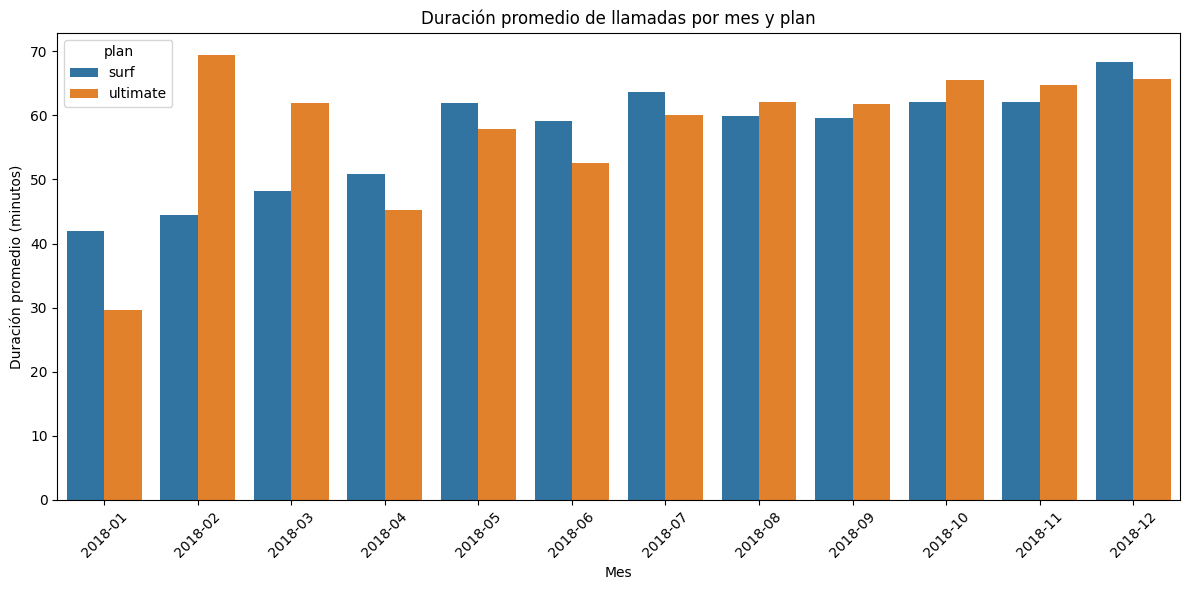

In [32]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
df_calls.info()
display(df_calls.head())

df_avg = df_resultado_2.groupby(['plan', 'year_month'])['#_llam'].mean().reset_index()


plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg, x='year_month', y='#_llam', hue='plan')
plt.title('Duración promedio de llamadas por mes y plan')
plt.xticks(rotation=45)
plt.ylabel('Duración promedio (minutos)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena gráfica, la duración promedio mensual se puede comparar adecuadamente entre los dos conjuntos de datos.
</div>

,plan,year_month,min_mes
0,surf,2018-01,278.850000
1,surf,2018-02,313.240000
2,surf,2018-03,324.985625
3,surf,2018-04,346.206286
4,surf,2018-05,418.675283
5,surf,2018-06,401.525429
6,surf,2018-07,426.454382
7,surf,2018-08,404.183950
8,surf,2018-09,402.010068
9,surf,2018-10,417.628785


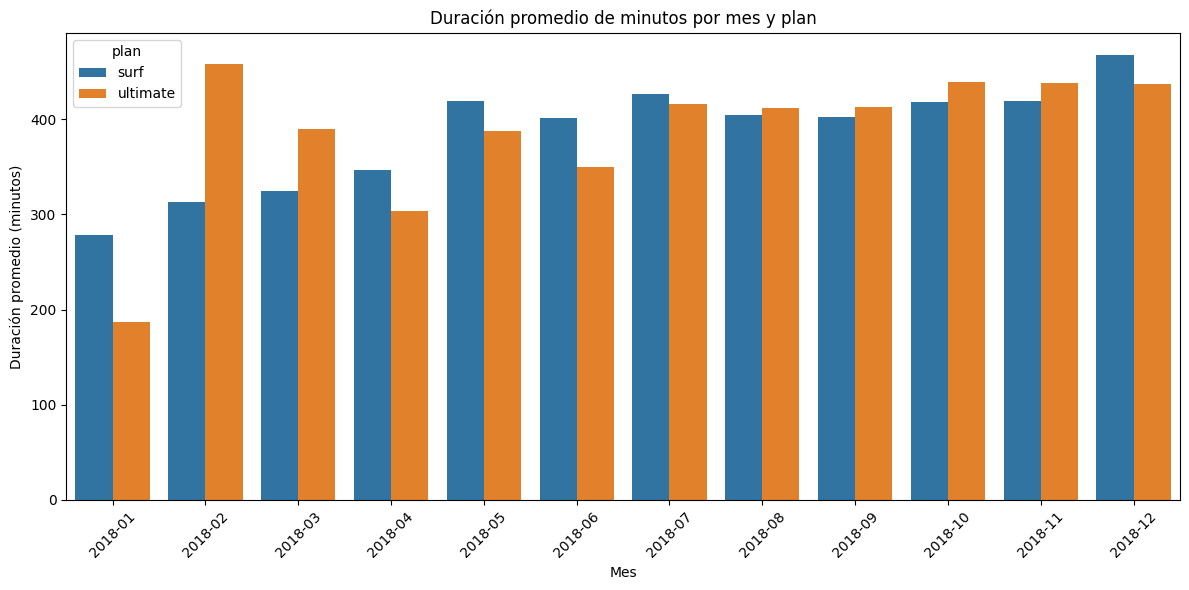

In [33]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

#numero de minutos al mes

df_avg2 = df_resultado_2.groupby(['plan', 'year_month'])['min_mes'].mean().reset_index()
display(df_avg2)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg2, x='year_month', y='min_mes', hue='plan')
plt.title('Duración promedio de minutos por mes y plan')
plt.xticks(rotation=45)
plt.ylabel('Duración promedio (minutos)')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, aunque aquí estás comparando los minutos al mes promedio de cada mes, en realidad debería ser a nivel usuario, así tendrías mas de 12 valores en cada grupo y tendría más sentido realizar el histograma.
</div>

In [34]:
# Calcula la media y la varianza de la duración mensual de llamadas.

# Media
media_min = df_avg2['min_mes'].mean()

# Varianza
varianza_min = df_avg2['min_mes'].var()

print(f"Media de duración mensual de llamadas: {media_min:.2f} minutos")
print(f"Varianza de duración mensual de llamadas: {varianza_min:.2f}")

Media de duración mensual de llamadas: 385.43 minutos
Varianza de duración mensual de llamadas: 4241.45


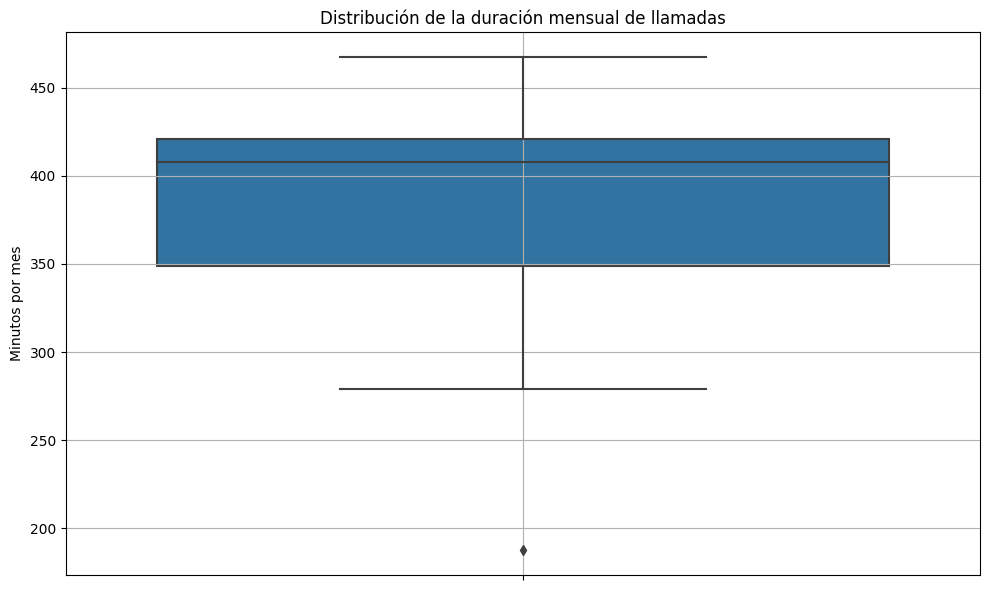

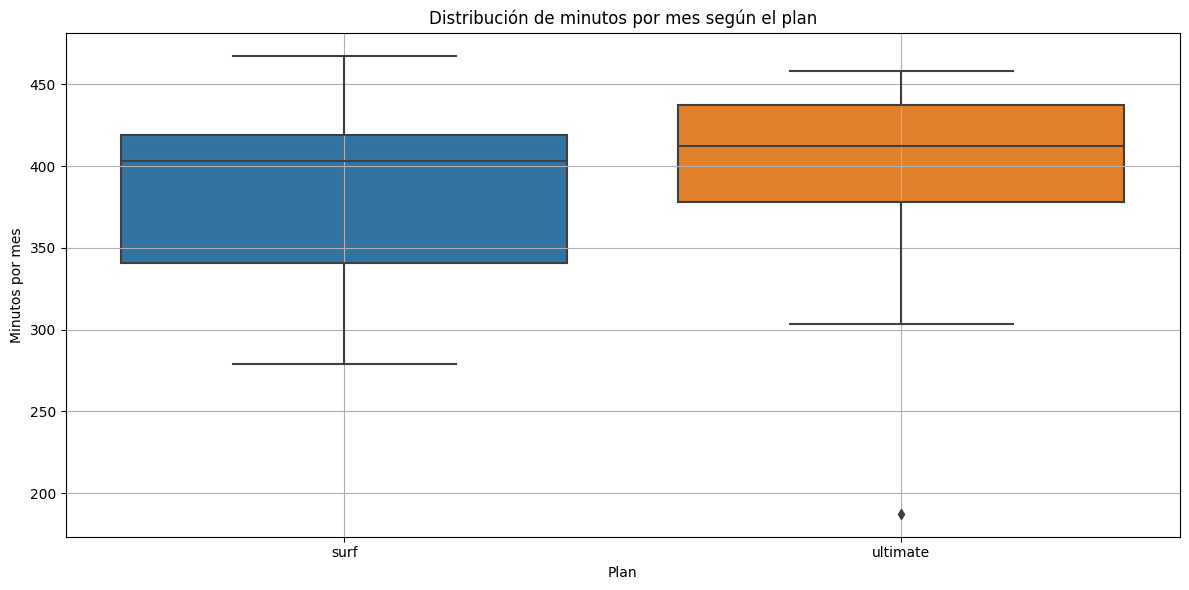

In [35]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_avg2, y='min_mes')
plt.title('Distribución de la duración mensual de llamadas')
plt.ylabel('Minutos por mes')
plt.xlabel('')
plt.tight_layout()
plt.grid(True) 
plt.show()



plt.figure(figsize=(12, 6))
sns.boxplot(data=df_avg2, x='plan', y='min_mes')
plt.title('Distribución de minutos por mes según el plan')
plt.xlabel('Plan')
plt.ylabel('Minutos por mes')
plt.tight_layout()
plt.grid(True) 
plt.show()

📌En el primer grafico, se observa que se realizo mas cantidad de llamadas con el pla ultimate, fuera de ese mes, no varian tanto con respecto al plan surf, incluso en seis meses llevo a tener mas llamadas con ese plan (surf) fuera de eso, van muy parecidos en cuanto a las llamadas

se observa que para las llamadas, su mediana esta por 410 para el plan Ultimate, mientras que para el plan Surf esta en 402, el valor minim

Se observa que hay menos dispersión fuera del rango IQ.

No hay mucha variacion entre los extremos, aunque es muy similar a Ultimate, solo que este si tiene algunos valores completamente duera de los quatiles

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, las gráficas de caja se han realizado correctamente. Se pueden comparar ambos planes.
</div>

### Mensajes

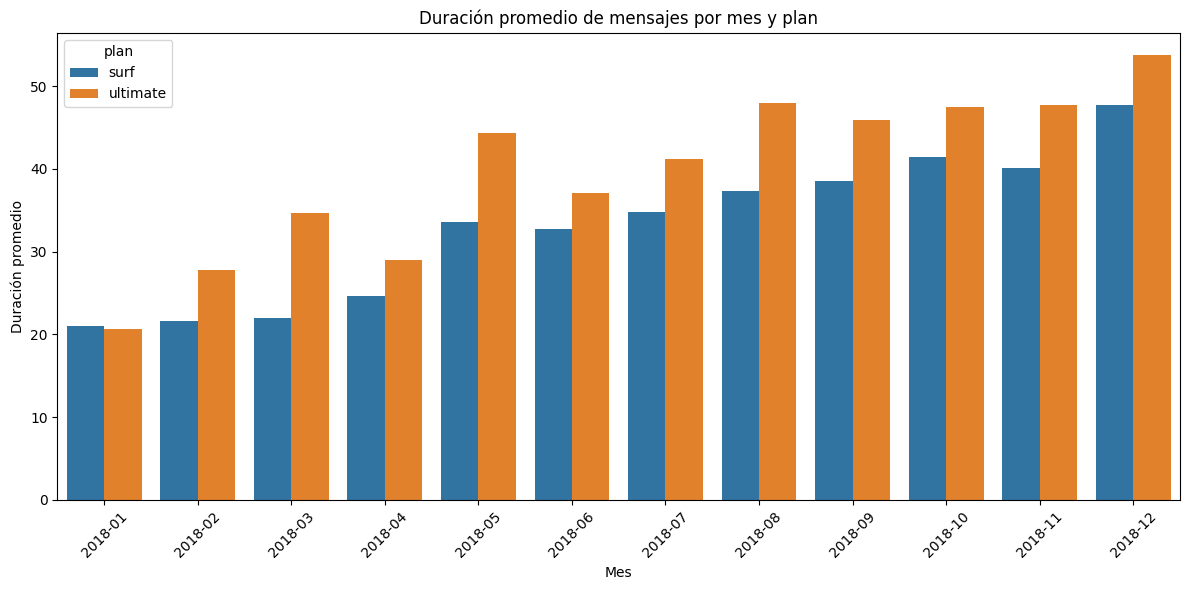

In [36]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

df_avg_mens = df_resultado_2.groupby(['plan', 'year_month'])['#_sms'].mean().reset_index()


plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_mens, x='year_month', y='#_sms', hue='plan')
plt.title('Duración promedio de mensajes por mes y plan')
plt.xticks(rotation=45)
plt.ylabel('Duración promedio')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Bien, estas gráficas son muy buenas, las barras representan correctamente los dos tipos de planes.
</div>

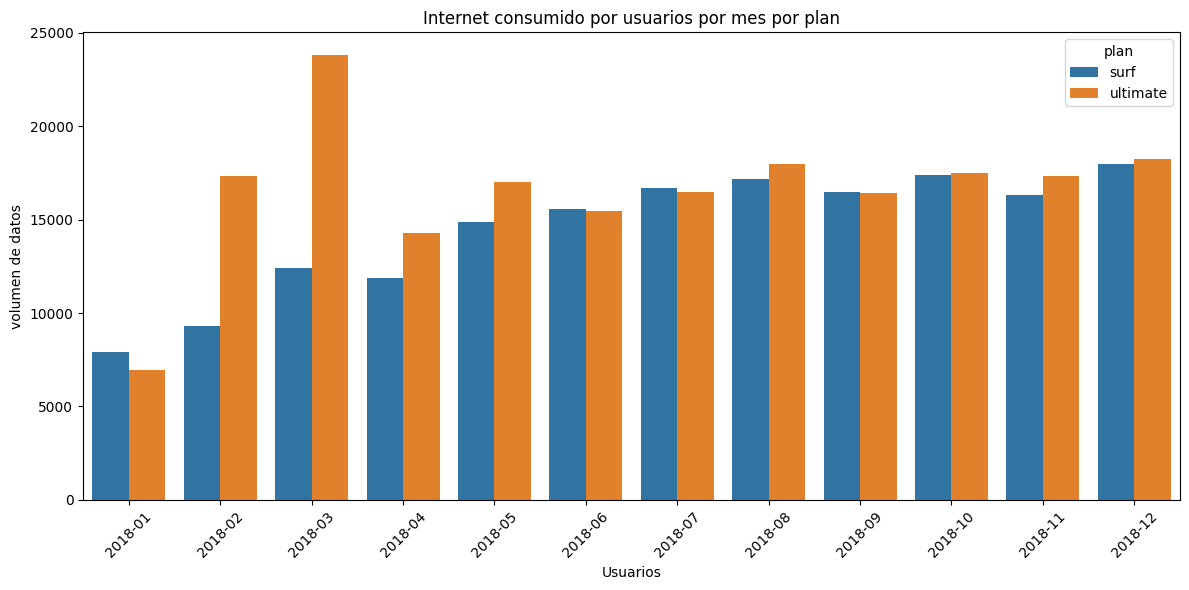

"\n\n\n\ndf_avg_inter = df_resultado_2.groupby(['plan', 'year_month'])['vol_Inte'].mean().reset_index()\n\nplt.figure(figsize=(12, 6))\nsns.barplot(data=df_avg_inter, x='year_month', y='vol_Inte', hue='plan')\nplt.title('Internet consumido por usuarios por mes por plan')\nplt.xticks(rotation=45)\nplt.ylabel('volumen de datos')\nplt.xlabel('Usuarios')\nplt.tight_layout()\nplt.show()\n\ndf_avg_inter = df_resultado_2.groupby(['plan', 'id_usr'])['vol_Inte'].mean().reset_index()\n\nplt.figure(figsize=(12, 6))\nsns.barplot(data=df_avg_inter, x='id_usr', y='vol_Inte', hue='plan')\nplt.title('Internet consumido por usuarios por plan')\nplt.xticks(rotation=45)\nplt.ylabel('volumen de datos')\nplt.xlabel('Usuarios')\nplt.tight_layout()\nplt.show()\n"

In [37]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

df_avg_inter = df_resultado_2.groupby(['plan', 'year_month'])['vol_Inte'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_inter, x='year_month', y='vol_Inte', hue='plan')
plt.title('Internet consumido por usuarios por mes por plan')
plt.xticks(rotation=45)
plt.ylabel('volumen de datos')
plt.xlabel('Usuarios')
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Para esta sección se debería realizar dos histogramas para poder comparar los dos tipos de planes.
</div>

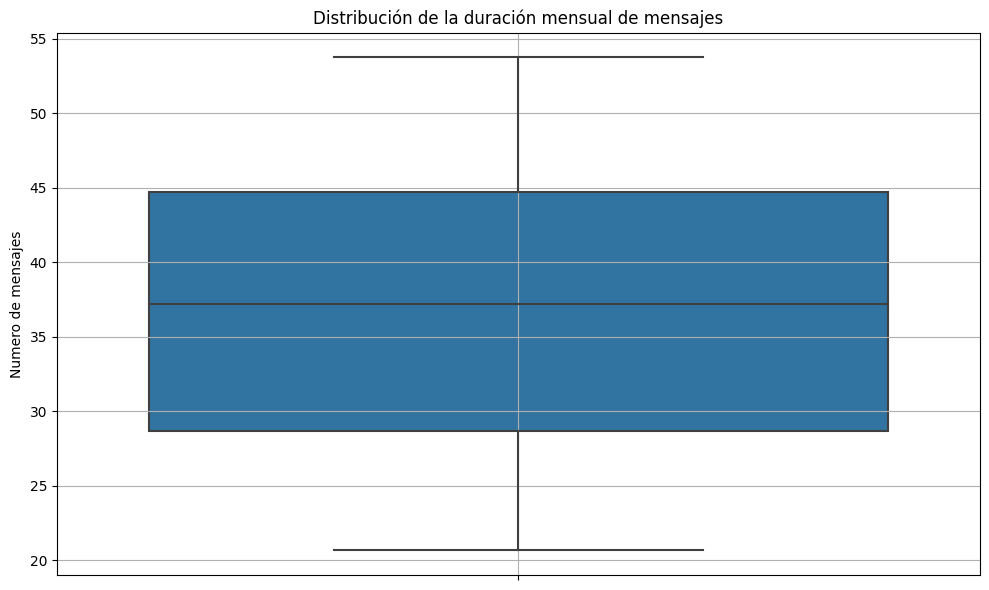

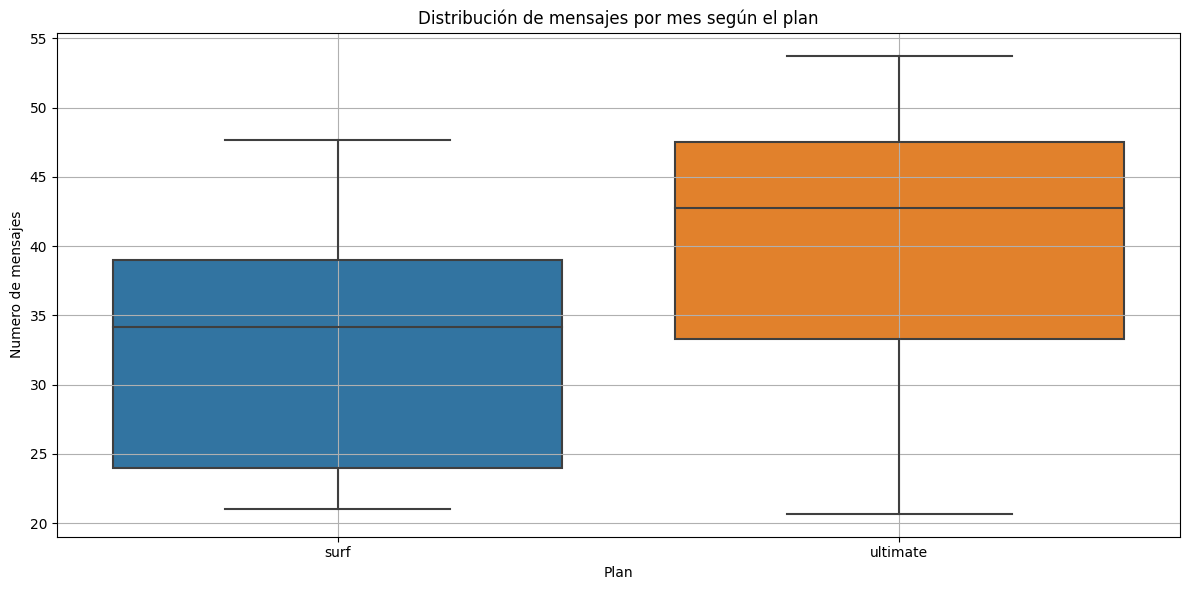

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_avg_mens, y='#_sms')
plt.title('Distribución de la duración mensual de mensajes')
plt.ylabel('Numero de mensajes')
plt.xlabel('')
plt.tight_layout()
plt.grid(True) 
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_avg_mens, x='plan', y='#_sms')
plt.title('Distribución de mensajes por mes según el plan')
plt.xlabel('Plan')
plt.ylabel('Numero de mensajes')
plt.tight_layout()
plt.grid(True) 
plt.show()


In [39]:
# Media
media_mens = df_resultado_2['#_sms'].mean()

# Varianza
varianza_mens = df_resultado_2['#_sms'].var()

print(f"Media de duración mensual de mensajes: {media_mens:.2f} mensajes")
print(f"Varianza de duración mensual de mensajes: {varianza_mens:.2f}")


Media de duración mensual de mensajes: 41.78 mensajes
Varianza de duración mensual de mensajes: 1067.55


📌En el primer grafico, se observa que los usuario envian mas mensajes con el plan ultimate, que con el plan de surf

se observa que los mensajes su mediana esta por 34 de mensajes, su mediana esta por 43 para el plan Ultimate, mientras que para el plan Surf esta en sus rangos esta entre 22 y 48 , miestras que para el plan Ultimate va de 22 a 53

Se observa que hay menos dispersión fuera del rango IQ.

No hay mucha variacion entre los extremos, aunque es muy similar a Ultimate, solo que este si tiene algunos valores completamente duera de los quatiles

📌Plan surf.-
La mediana está alrededor de 33-35 minutos, el rango va desde aprox. 22 hasta 48 minutos.

Esto sugiere un uso más moderado y consistente.

📌Plan ultimate.-
La mediana es mayor, como en 42-44 minutos, su rango es mayor va de 21 a 53 minutos.

📌El plan de Ultimate  los usuarios usan mas los minutos en los meses a diferencia de Surf 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buenos comentarios, basados en lo observado en las gráficas y las métricas de los mensajes.
</div>

### Internet

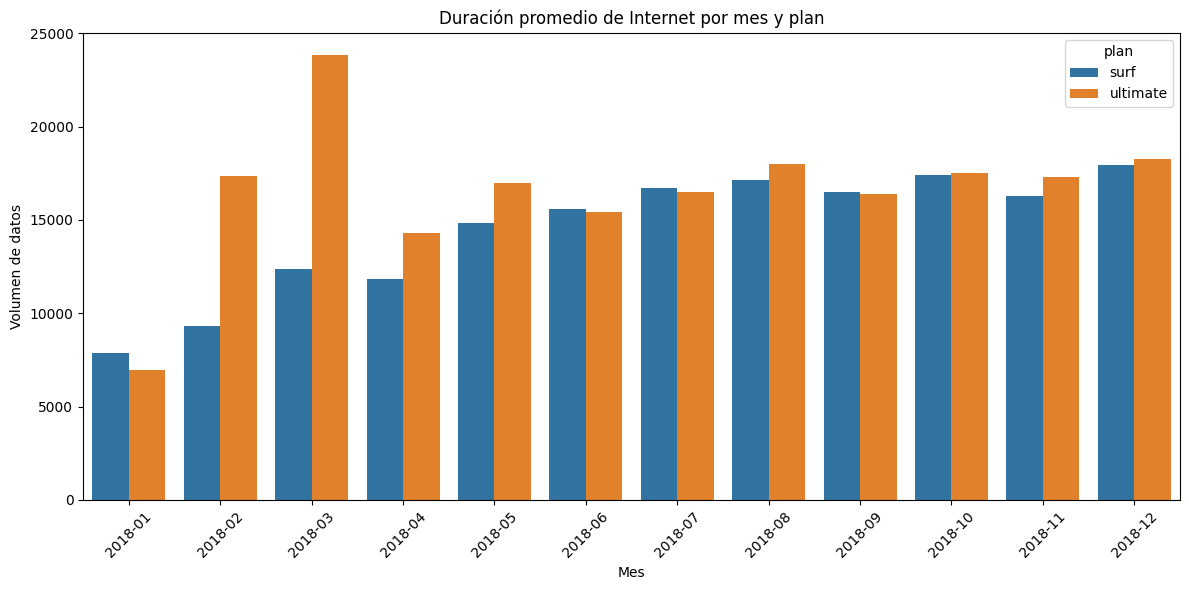

In [40]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

df_avg_inter = df_resultado_2.groupby(['plan', 'year_month'])['vol_Inte'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_inter, x='year_month', y='vol_Inte', hue='plan')
plt.title('Duración promedio de Internet por mes y plan')
plt.xticks(rotation=45)
plt.ylabel('Volumen de datos')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


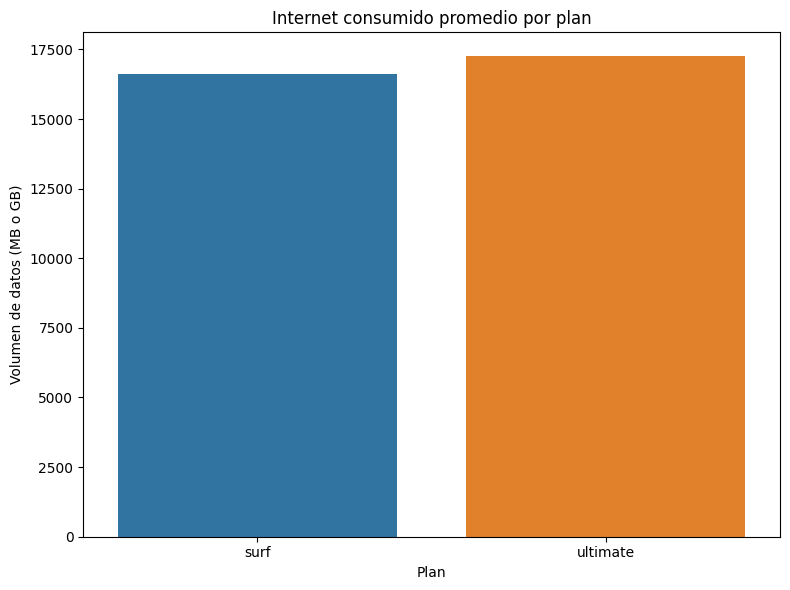

"\ndf_avg_inter = df_resultado_2.groupby(['plan', 'id_usr'])['vol_Inte'].mean().reset_index()\n\nplt.figure(figsize=(12, 6))\nsns.barplot(data=df_avg_inter, x='id_usr', y='vol_Inte', hue='plan')\nplt.title('Internet consumido por usuarios por plan')\nplt.xticks(rotation=45)\nplt.ylabel('volumen de datos')\nplt.xlabel('Usuarios')\nplt.tight_layout()\nplt.show()\n\n"

In [41]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan


df_avg_inter = df_resultado_2.groupby('plan')['vol_Inte'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=df_avg_inter, x='plan', y='vol_Inte')
plt.title('Internet consumido promedio por plan')
plt.ylabel('Volumen de datos (MB o GB)')
plt.xlabel('Plan')
plt.tight_layout()
plt.show()

'''
df_avg_inter = df_resultado_2.groupby(['plan', 'id_usr'])['vol_Inte'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_inter, x='id_usr', y='vol_Inte', hue='plan')
plt.title('Internet consumido por usuarios por plan')
plt.xticks(rotation=45)
plt.ylabel('volumen de datos')
plt.xlabel('Usuarios')
plt.tight_layout()
plt.show()

'''


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Aquí también se tienen que hacer dos histogramas, para poder comparar mejor estos dos conjuntos de datos.
</div>

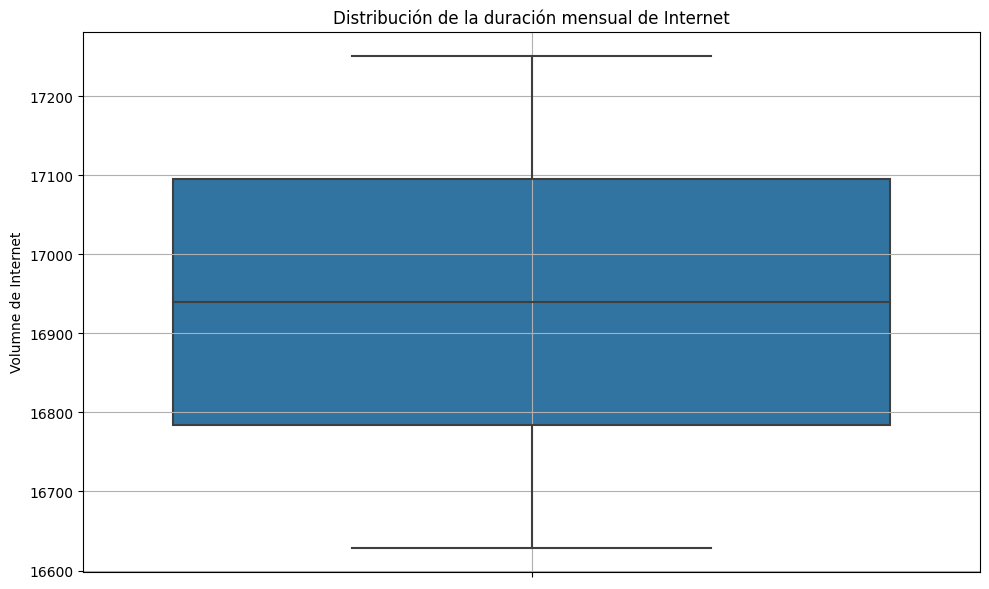

********************************************************************************
****************************************usuarios****************************************


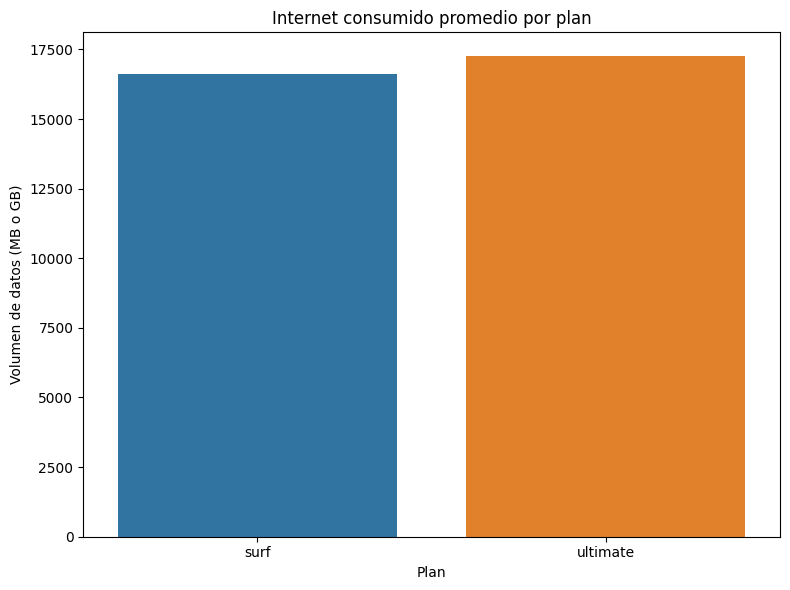

In [42]:
df_avg_inter = df_resultado_2.groupby('plan')['vol_Inte'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_avg_inter, y='vol_Inte')
plt.title('Distribución de la duración mensual de Internet')
plt.ylabel('Volumne de Internet')
plt.xlabel('')
plt.tight_layout()
plt.grid(True) 
plt.show()


print('*' * 80)
print('*' * 40 +'usuarios' + '*' * 40)



plt.figure(figsize=(8, 6))
sns.barplot(data=df_avg_inter, x='plan', y='vol_Inte')
plt.title('Internet consumido promedio por plan')
plt.ylabel('Volumen de datos (MB o GB)')
plt.xlabel('Plan')
plt.tight_layout()
plt.show()


In [43]:
# Media
media_mens = df_resultado_2['vol_Inte'].mean()

# Varianza
varianza_mens = df_resultado_2['vol_Inte'].var()

print(f"Media de duración mensual de Internet: {media_mens:.2f} mensajes")
print(f"Varianza de duración mensual de Internet: {varianza_mens:.2f}")


Media de duración mensual de Internet: 16833.75 mensajes
Varianza de duración mensual de Internet: 59423784.31


📌En el primer grafico, solo para dos meses el plan de Ultimate es el que tiene mayor actividad, fuera de eso no hay gran diferencia, no varian tanto con respecto al plan surf, incluso en seis meses llevo a tener mas llamadas con ese plan (surf) fuera de eso, van muy parecidos en cuanto a las llamadas

se observa que para las llamadas, su mediana esta por 410 para el plan Ultimate, mientras que para el plan Surf esta en 402, el valor minim

Se observa que hay menos dispersión fuera del rango IQ.

No hay mucha variacion entre los extremos, aunque es muy similar a Ultimate, solo que este si tiene algunos valores completamente duera de los quatiles


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buenos comentarios, basados en lo observado en estas gráficas.
</div>

## Ingreso

,id_usr,year_month,#_llam,min_mes,#_sms,vol_Inte,plan,sms_free,datos_free,min_free,...,datos_ext,sms_ext,min_ext,llama_t,sms_t,datos_t,extra_llam,extra_mens,extra_dat,ingreso_mensual
0,1000,2018-12,16,116.83,11,1901.47,ultimate,1000,30720,3000,...,7,0.01,0.01,2883.17,989,28818.53,0.0,0.00,0.000000,70.000000
1,1001,2018-08,27,171.14,30,6919.15,surf,50,15360,500,...,10,0.03,0.03,328.86,20,8440.85,0.0,0.00,0.000000,20.000000
2,1001,2018-09,49,297.69,44,13314.82,surf,50,15360,500,...,10,0.03,0.03,202.31,6,2045.18,0.0,0.00,0.000000,20.000000
3,1001,2018-10,65,374.11,53,22330.49,surf,50,15360,500,...,10,0.03,0.03,125.89,-3,-6970.49,0.0,0.09,68.071191,88.161191
4,1001,2018-11,64,404.59,36,18504.30,surf,50,15360,500,...,10,0.03,0.03,95.41,14,-3144.30,0.0,0.00,30.706055,50.706055


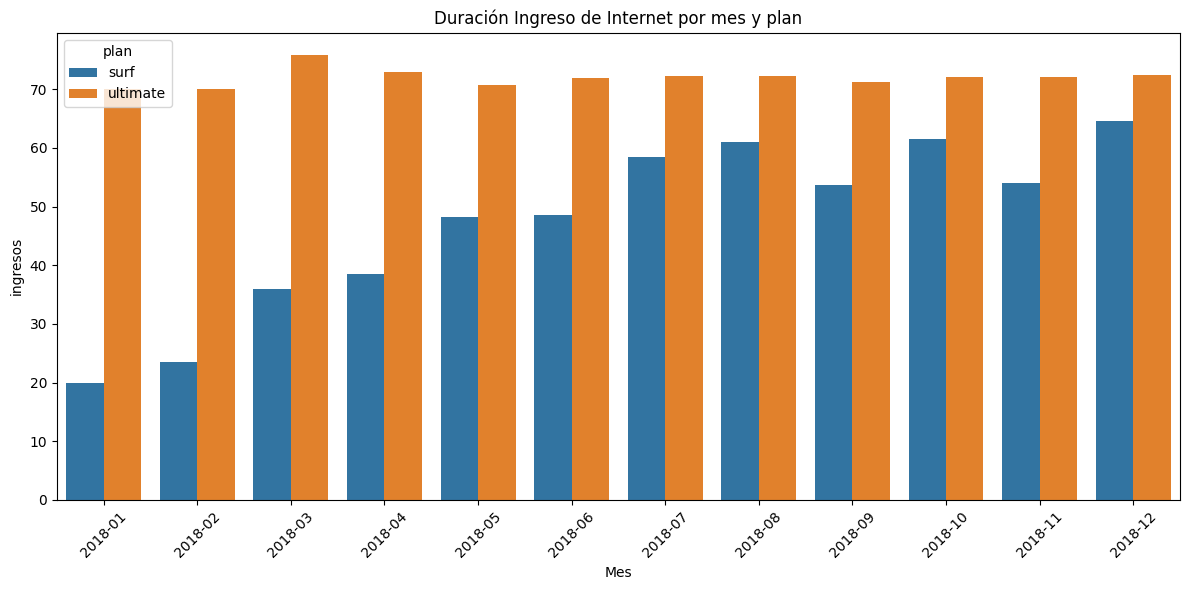

In [44]:
display(df_resultado_2.head())

df_avg_ingre = df_resultado_2.groupby(['plan', 'year_month'])['ingreso_mensual'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_avg_ingre, x='year_month', y='ingreso_mensual', hue='plan')
plt.title('Duración Ingreso de Internet por mes y plan')
plt.xticks(rotation=45)
plt.ylabel('ingresos')
plt.xlabel('Mes')
plt.tight_layout()
plt.show()


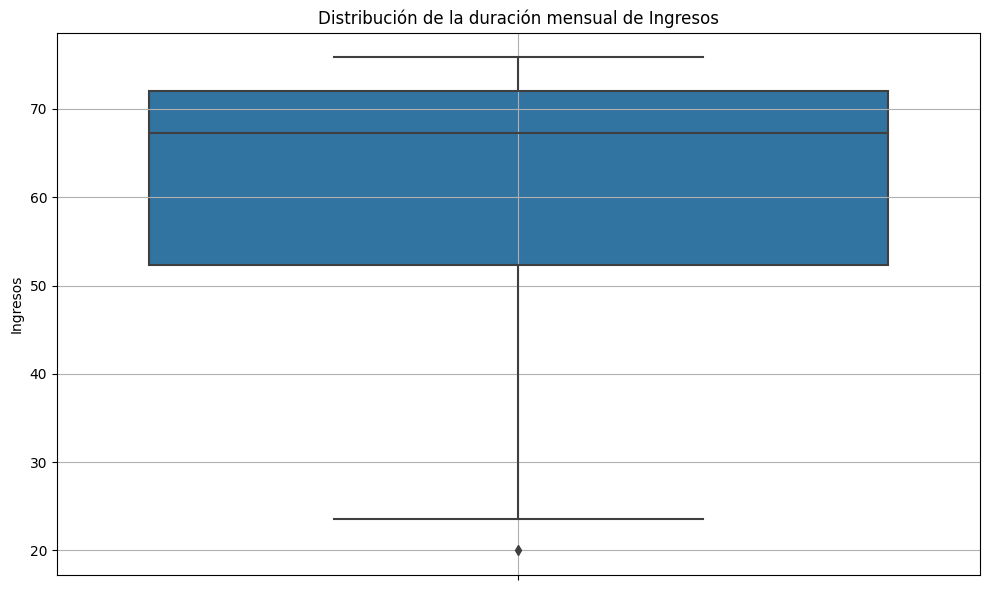

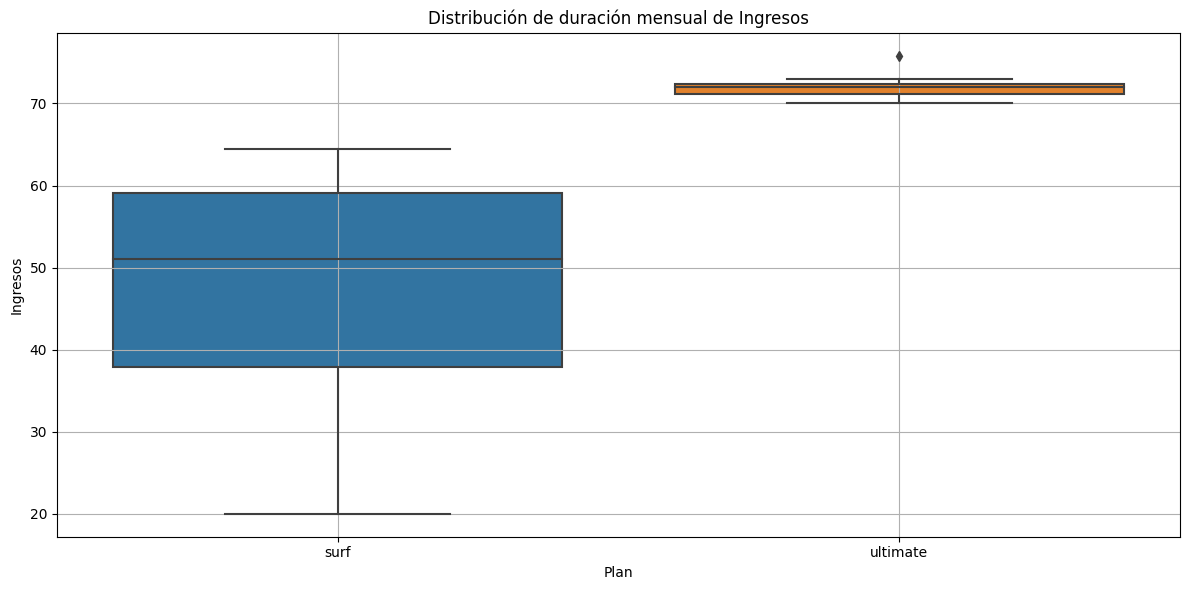

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_avg_ingre, y='ingreso_mensual')
plt.title('Distribución de la duración mensual de Ingresos')
plt.ylabel('Ingresos')
plt.xlabel('')
plt.tight_layout()
plt.grid(True) 
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_avg_ingre, x='plan', y='ingreso_mensual')
plt.title('Distribución de duración mensual de Ingresos')
plt.xlabel('Plan')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.grid(True) 
plt.show()

In [46]:
# Media
media_ingres = df_resultado_2['ingreso_mensual'].mean()

# Varianza
varianza_ingres = df_resultado_2['ingreso_mensual'].var()

print(f"Media de duración mensual de Ingresos: {media_ingres:.2f} ingreso")
print(f"Varianza de duración mensual de Ingresos: {varianza_ingres:.2f}")

Media de duración mensual de Ingresos: 61.88 ingreso
Varianza de duración mensual de Ingresos: 1888.55


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena comparación de los ingresos de ambos grupos.
</div>

📌la media de Surf esta en 51 y sus ingresos van en un rango de 20 a 65 y se aprecia que son muchos a diferencia de ultimate que su media esta por 74 con nun rango de 70 a 75 y son muy pocos

## Prueba las hipótesis estadísticas

📌 Hipótesis nula (H₀): Los ingresos promedio de ambos planes son diferentes.

Hipótesis alternativa (H₁): Los ingresos promedio de ambos planes son iguales.


In [47]:
display(df_avg_ingre.head())

,plan,year_month,ingreso_mensual
0,surf,2018-01,20.000000
1,surf,2018-02,23.535460
2,surf,2018-03,35.910969
3,surf,2018-04,38.531525
4,surf,2018-05,48.261003


In [48]:
# Prueba las hipótesis

print('*' * 80)
surf = df_avg_ingre[df_avg_ingre['plan'] == 'surf']['ingreso_mensual']

display(surf.head())


print('*' * 80)

ultimate = df_avg_ingre[df_avg_ingre['plan'] == 'ultimate']['ingreso_mensual']
display(ultimate.head())

print('*' * 80)

# Prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(surf, ultimate, equal_var=False)  # usamos Welch's t-test

print(f'Estadístico t: {t_stat:.3f}')
print(f'Valor p: {p_value:.4f}')

********************************************************************************


0    20.000000
1    23.535460
2    35.910969
3    38.531525
4    48.261003
Name: ingreso_mensual, dtype: float64

********************************************************************************


12    70.000000
13    70.000000
14    75.815625
15    73.008492
16    70.712184
Name: ingreso_mensual, dtype: float64

********************************************************************************
Estadístico t: -5.742
Valor p: 0.0001


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Muy bien! Se definieron correctamente las hipótesis y se interpretó adecuadamente el p valor.
</div>

📌 Hipótesis nula (H₀):
El ingreso promedio de los usuarios de NY-NJ es diferente  al de los usuarios de otras regiones.

Hipótesis alternativa (H₁):
El ingreso promedio de los usuarios de NY-NJ es igual al de los usuarios de otras regiones.



In [49]:
# Prueba las hipótesis

df_users_ny_nj = df_users[['user_id', 'age', 'city', 'plan']].rename(columns={'user_id': 'id_usr'})

df_users_ny_nj['pais_abrev'] = df_users_ny_nj['city'].str.split(',').str[1]

print('*' * 80) 
print('*' * 40 +'filtro sin ser NY-NJ' + '*' * 40)
df_users_ny_nj_1 = df_users_ny_nj

filtro = df_users_ny_nj_1['pais_abrev'] != 'NY-NJ'
usuarios_fuera_ny_nj = df_users_ny_nj_1[filtro]

print('*' * 80) 
df_1_ny = df_users_ny_nj_1.merge(df_resultado_2, on='id_usr')


df_1_ny_2=df_1_ny[['id_usr','age','plan_x','pais_abrev','year_month','#_llam','min_mes','#_sms','vol_Inte','ingreso_mensual']]

display(df_1_ny_2.head())
print('*' * 80) 
print('*' * 40 +'filtro con ser NY-NJ' + '*' * 40)
filtro2 = df_users_ny_nj_1['pais_abrev'] == 'NY-NJ'
print('*' * 80) 

filtro2 = df_users_ny_nj_1['pais_abrev'] == 'NY-NJ'
usuarios_fuera_ny_nj = df_users_ny_nj_1[filtro2]
print('*' * 80) 


********************************************************************************
****************************************filtro sin ser NY-NJ****************************************
********************************************************************************


,id_usr,age,plan_x,pais_abrev,year_month,#_llam,min_mes,#_sms,vol_Inte,ingreso_mensual
0,1000,45,ultimate,GA MSA,2018-12,16,116.83,11,1901.47,70.000000
1,1001,28,surf,WA MSA,2018-08,27,171.14,30,6919.15,20.000000
2,1001,28,surf,WA MSA,2018-09,49,297.69,44,13314.82,20.000000
3,1001,28,surf,WA MSA,2018-10,65,374.11,53,22330.49,88.161191
4,1001,28,surf,WA MSA,2018-11,64,404.59,36,18504.30,50.706055


********************************************************************************
****************************************filtro con ser NY-NJ****************************************
********************************************************************************
********************************************************************************


## Conclusión general

📌por todo lo antes mencionado, es mejor el plan Surf, tiene más usuario y hay más entradas al contrario de los Ultimate

- La mayoría de los datos estaban bien solo, varios campos que estaban como objeto se tuvieron que cambiar al tipo de dato de fecha para poder obtener y saber sobre qué mes es para la parte de agrupaciones, en este caso mantuve el año, por si más adelante deciden agregar más registros, no sea tan complicado, ya que se podría trabajar bien al saber que ese mes corresponde a determinado año.

- Igual de la tabla de **Internet** se le quitaron todos los registros cuyo valor del volumen de datos gastados durante dichas sesiones fueron 0, ya que esos registros no le aportan nada, fueron 13,747 registro, lo cual hacen un 13.11 % de los datos, por lo que no es un gran impacto al momento de quitarlos, de hecho no se eliminaron, pero si se aplicó filtros y se trabajó con tablas auxiliares, para evitar la pérdida de información.

- También se observaron que 466 **usuarios** estaban usando datos cuando se realizó el respaldo de las tablas. Estos no se eliminaron, solo se ignoró esa columna, ya que no aportaba a las operaciones, en la sesión de agregar datos, se agregó una columna del año-mes **year_month**, también se realizaron las operaciones necesarias para obtener el ingreso mensual para cada usuario, dependiendo del plan, sms, llamadas

- También con la tabla de **llamadas** se realizó lo mismo se le aplico un filtro para las llamadas que tuvieron una duración de 0 minutos

- Casi al final se obtuvo una tabla que única todas, con esta unión de tablas se pudo realizar varios grafico

 **Estudia el comportamiento de usuario** esto a partir de las graficas
- Llamadas:
- la mayoría de las llamadas para el plan surf van de los 41 minutos hasta 65 minutos  vs el plan ultimate están van de 30 minutos hasta los 78 minutos
- la duración promedio de minutos por mes para surf van de los 280 minutos a los 460 minutos vs el ultimate que va de los 180 minutos a los 470 minutos
- se obtuvo una Media de duración mensual de llamadas: 385.43 minutos

- Varianza de duración mensual de llamadas: 4241.45

- la destrucción de las llamadas va de los 270 a los 470 minutos observando el grafico de caja vs el ultimate va de 310 a 460

- la distribución de los minutos por plan para surf va de 270 a 470

- en cuestión de mensajes la duración que por mes se tuvo en el plan surf fue de 21 a 46 v el ultimate que fue de 20 a 55 de duración

- el consumo de dato de Internet, van muy empatadas, a excepción de 2 meses(febrero, ,marzo) se tendría que analizarlo mejor por país o ver si ocurrió algo por esas fechas para sacar una conclusión sobre porque en esos meses el plan ultimate tuvo un mayor número de consumo, lo que se me ocurre es que hubo alguna promoción o algo por el 14 de febrero y por ser el próximo el 10 de mayo, solo son conjeturas que necesitaría  revisar con más escrutinio sobre esos 2 meses

- la distribución de los mensajes para surf va de 24 a 47 mensajes vs 22 a 53 de utimate

- el internet consumido por plan para surf va de 0 a 16000 vs 0 a 17400

- en cuanto a los ingresos por plan se observa muy diferente los de surf vs el de ultimate, este se son más constantes al largo de todos os meses los ingresos a diferencia del surf, los de surf van de 20 a 65, mientras que los de ultimate van de 70 a 80




<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buenas conclusiones, aunque están un poco cortas para ser las conclusiones finales, se pueden completar con algunos descubrimientos, o mencionar algo sobre la limpieza de los datos y sobre la exploración de las tablas.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Hola!
    
Te quiero felicitar por tu proyecto, está bastante completo y bien realizado, me gustaron especialmente las gráficas y la manera correcta de definir todas las columnas en las tablas. Solo falta realizar un par de cambios para que esté completo, estos cambios los encontraras en bloques de color rojo. Sé que podrás realizarlos de manera adecuada.
    
Saludos y éxito.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Bien hecho!
    
Gracias por atender a los comentarios.
    
Éxito en los siguientes sprints.
</div>